# Figure 2a-d: I-Z Spectroscopy 2D Histograms
2D histogram plots comparing I-Z spectra at different setpoint currents (80, 150, 200, 250 pA)

In [1]:
import os
import numpy as np
import xarray as xr
import holoviews as hv
import rhkpy
import requests

hv.extension('matplotlib')

In [2]:
import sys
print(f'Python version: {sys.version}')
print(f'numpy version: {np.__version__}')
print(f'xarray version: {xr.__version__}')
print(f'holoviews version: {hv.__version__}')
print(f'rhkpy version: {rhkpy.__version__}')

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 11:23:37) [Clang 14.0.6 ]
numpy version: 2.3.1
xarray version: 2025.6.1
holoviews version: 1.21.0
rhkpy version: 1.3.9


In [3]:
# Download source files from Zenodo if missing
ZENODO_FILES = {
    'iz_c100.sm4': 'https://zenodo.org/records/17469441/files/I-Z_Kalvin_HOPG_UHV_exf240717_9K_2024_07_22_15_53_14_141.sm4?download=1',
    'iz_c150.sm4': 'https://zenodo.org/records/17469441/files/I-Z_Kalvin_HOPG_UHV_exf240717_9K_2024_07_22_15_55_17_818.sm4?download=1',
    'iz_c200.sm4': 'https://zenodo.org/records/17469441/files/I-Z_Kalvin_HOPG_UHV_exf240717_9K_2024_07_22_15_58_02_901.sm4?download=1',
    'iz_c250.sm4': 'https://zenodo.org/records/17469441/files/I-Z_Kalvin_HOPG_UHV_exf240717_9K_2024_07_22_16_00_20_383.sm4?download=1',
    'iz_map_out.sm4': 'https://zenodo.org/records/17469441/files/Stripes-9K-HOPG-SPI2-3_2021_09_09_05_50_41_043.sm4?download=1',
    'iz_map_in2.sm4': 'https://zenodo.org/records/17469441/files/MK_ABC_FLG_25_9K_2023_10_19_11_29_53_727.sm4?download=1',
    'iz_map_in3.sm4': 'https://zenodo.org/records/17469441/files/MK_ABC_FLG_25_9K_2023_10_24_10_15_58_878.sm4?download=1',
    'iz_map_in4.sm4': 'https://zenodo.org/records/17469441/files/MK_ABC_FLG_25_9K_2023_11_08_06_52_20_288.sm4?download=1',
}

for local, url in ZENODO_FILES.items():
    if url is None or os.path.exists(local):
        continue
    print(f'Downloading {local}...')
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    with open(local, 'wb') as fh:
        fh.write(response.content)
    print(f'✓ {local} downloaded')

In [4]:
# Load UHV cleaved reference spectra at different setpoints
iz_c100 = rhkpy.rhkdata('iz_c100.sm4').mrep().msw()
iz_c150 = rhkpy.rhkdata('iz_c150.sm4').mrep().msw()
iz_c200 = rhkpy.rhkdata('iz_c200.sm4').mrep().msw()
iz_c250 = rhkpy.rhkdata('iz_c250.sm4').mrep().msw()

# Convert z coordinates to Angstroms
for ds in [iz_c100, iz_c150, iz_c200, iz_c250]:
    ds.spectra['z'] = ds.spectra['z'] * 10

In [5]:
# Helper functions for data processing
def process_iz_map(filename):
    """Load and process I-Z map data"""
    iz_map = rhkpy.rhkdata(filename)
    
    # Separate up and down scans
    iz_up = iz_map.spectra.current.sel(zscandir='up')
    iz_down = iz_map.spectra.current.sel(zscandir='down')
    iz_up['z'] = iz_up.z[::-1].data
    
    # Stack all spectra dimensions
    iz_up = iz_up.stack(allspec=('repetitions', 'specpos_x', 'specpos_y'))
    iz_up = iz_up.drop_vars(['specpos_x', 'specpos_y', 'repetitions'])
    iz_up = iz_up.assign_coords(allspec=iz_up['allspec'])
    iz_up['z'] = iz_up['z'] * 10
    iz_up['z'] = iz_up.z[::-1].data
    iz_up.data = np.abs(iz_up.data)
    
    iz_down = iz_down.stack(allspec=('repetitions', 'specpos_x', 'specpos_y'))
    iz_down = iz_down.drop_vars(['specpos_x', 'specpos_y', 'repetitions'])
    iz_down = iz_down.assign_coords(allspec=iz_down['allspec'])
    iz_down['z'] = iz_down['z'] * 10
    iz_down.data = np.abs(iz_down.data)
    
    # Stack all for histogram
    iz_map.spectra = iz_map.spectra.stack(allspec=('repetitions', 'specpos_x', 'specpos_y', 'zscandir'))
    iz_map.spectra['z'] = iz_map.spectra['z'] * 10
    iz_map.spectra.current.data = np.abs(iz_map.spectra.current.data)
    
    return iz_map, iz_up, iz_down

def create_histogram_plot(iz_map, title, ref_spec, ref_label='UHV cleaved'):
    """Create 2D histogram plot with overlaid mean spectra"""
    iz_data = iz_map.spectra.current
    global_min, global_max = iz_data.min().values, iz_data.max().values
    
    hist_data = []
    for z_val in iz_data['z'].values:
        current_data = iz_data.sel(z=z_val).values
        hist, bin_edges = np.histogram(current_data, bins=200, range=(global_min, global_max))
        hist_data.append(hist)
    
    hist_data = np.array(hist_data)
    current_bins = (bin_edges[:-1] + bin_edges[1:]) / 2
    hist_da = xr.DataArray(
        hist_data.T, 
        coords=[current_bins, iz_data['z'].values], 
        dims=['current', 'z'],
        name='counts'
    )
    
    # Create base histogram image
    hist_plot = hv.Image(hist_da, kdims=['z', 'current']).opts(
        logz=True,
        cmap='gray_r',
        xlabel='tip sample distance (Å)',
        ylabel='tunneling current (pA)',
        clabel='counts',
        ylim=(0, 300),
        colorbar=True,
        aspect=1.1,
        fig_inches=3,
        title=title
    )
    
    return hist_plot, iz_data

:Overlay
   .Image.I           :Image   [z,current]   (counts)
   .Curve.UHV_cleaved :Curve   [z]   (current)
   .Curve.Backward    :Curve   [z]   (current)
   .Curve.Forward     :Curve   [z]   (current)
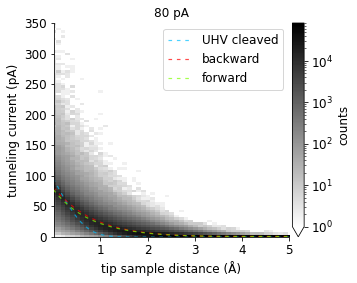

In [6]:
# Process 80 pA data
iz_map_out, iz_out_up, iz_out_down = process_iz_map('iz_map_out.sm4')

hist_plot_out, _ = create_histogram_plot(iz_map_out, '80 pA', iz_c100.spectra.sel(z=slice(0, 5)).current)

# Add mean spectra overlays
plot_uhv = iz_c100.spectra.sel(z=slice(0, 5)).current.hvplot.line(x='z', label='UHV cleaved').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='deepskyblue', linewidth=1.2, fig_inches=2
)
plot_up = iz_out_up.mean(dim='allspec').hvplot.line(x='z', label='backward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='red', linewidth=1.2, fig_inches=2
)
plot_down = iz_out_down.mean(dim='allspec').hvplot.line(x='z', label='forward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='chartreuse', linewidth=1.2, fig_inches=2
)

plot_80pA = (hist_plot_out * plot_uhv * plot_up * plot_down).opts(
    xlim=(0.01, 5), ylim=(0, 350), aspect=1.1, fig_inches=2,
    fontsize={'title': 12, 'labels': 12, 'xticks': 12, 'yticks': 12, 'cticks': 12, 'legend': 12}
)
plot_80pA

In [7]:
# hv.save(plot_80pA, 'fig2a_80pA.svg', fmt='svg')

:Overlay
   .Image.I           :Image   [z,current]   (counts)
   .Curve.UHV_cleaved :Curve   [z]   (current)
   .Curve.Backward    :Curve   [z]   (current)
   .Curve.Forward     :Curve   [z]   (current)
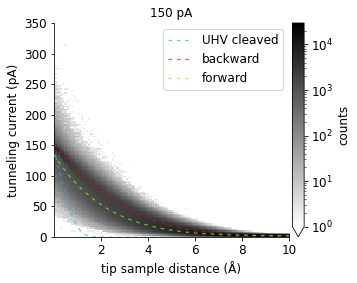

In [8]:
# Process 150 pA data
iz_map_in2, iz_in2_up, iz_in2_down = process_iz_map('iz_map_in2.sm4')

hist_plot_in2, _ = create_histogram_plot(iz_map_in2, '150 pA', iz_c150.spectra.current)

plot_uhv_150 = iz_c150.spectra.current.hvplot.line(x='z', label='UHV cleaved').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='deepskyblue', linewidth=1.2, fig_inches=2
)
plot_up_150 = iz_in2_up.mean(dim='allspec').hvplot.line(x='z', label='backward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='red', linewidth=1.2, fig_inches=2
)
plot_down_150 = iz_in2_down.mean(dim='allspec').hvplot.line(x='z', label='forward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='chartreuse', linewidth=1.2, fig_inches=2
)

plot_150pA = (hist_plot_in2 * plot_uhv_150 * plot_up_150 * plot_down_150).opts(
    xlim=(0.01, 10), ylim=(0, 350), aspect=1.1, fig_inches=2,
    fontsize={'title': 12, 'labels': 12, 'xticks': 12, 'yticks': 12, 'cticks': 12, 'legend': 12}
)
plot_150pA

In [9]:
# hv.save(plot_150pA, 'fig2b_150pA.svg', fmt='svg')

:Overlay
   .Image.I           :Image   [z,current]   (counts)
   .Curve.UHV_cleaved :Curve   [z]   (current)
   .Curve.Backward    :Curve   [z]   (current)
   .Curve.Forward     :Curve   [z]   (current)
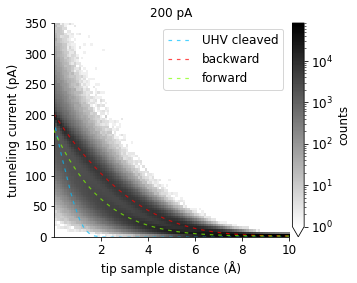

In [10]:
# Process 200 pA data
iz_map_in3, iz_in3_up, iz_in3_down = process_iz_map('iz_map_in3.sm4')

hist_plot_in3, _ = create_histogram_plot(iz_map_in3, '200 pA', iz_c200.spectra.current)

plot_uhv_200 = iz_c200.spectra.current.hvplot.line(x='z', label='UHV cleaved').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='deepskyblue', linewidth=1.2, fig_inches=2
)
plot_up_200 = iz_in3_up.mean(dim='allspec').hvplot.line(x='z', label='backward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='red', linewidth=1.2, fig_inches=2
)
plot_down_200 = iz_in3_down.mean(dim='allspec').hvplot.line(x='z', label='forward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='chartreuse', linewidth=1.2, fig_inches=2
)

plot_200pA = (hist_plot_in3 * plot_uhv_200 * plot_up_200 * plot_down_200).opts(
    xlim=(0.01, 10), ylim=(0, 350), aspect=1.1, fig_inches=2,
    fontsize={'title': 12, 'labels': 12, 'xticks': 12, 'yticks': 12, 'cticks': 12, 'legend': 12}
)
plot_200pA

In [11]:
# hv.save(plot_200pA, 'fig2c_200pA.svg', fmt='svg')

:Overlay
   .Image.I           :Image   [z,current]   (counts)
   .Curve.UHV_cleaved :Curve   [z]   (current)
   .Curve.Backward    :Curve   [z]   (current)
   .Curve.Forward     :Curve   [z]   (current)
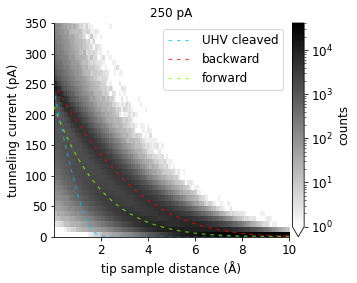

In [12]:
# Process 250 pA data
iz_map_in4, iz_in4_up, iz_in4_down = process_iz_map('iz_map_in4.sm4')

hist_plot_in4, _ = create_histogram_plot(iz_map_in4, '250 pA', iz_c250.spectra.current)

plot_uhv_250 = iz_c250.spectra.current.hvplot.line(x='z', label='UHV cleaved').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='deepskyblue', linewidth=1.2, fig_inches=2, xlim=(0.01, 10)
)
plot_up_250 = iz_in4_up.mean(dim='allspec').hvplot.line(x='z', label='backward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='red', linewidth=1.2, fig_inches=2
)
plot_down_250 = iz_in4_down.mean(dim='allspec').hvplot.line(x='z', label='forward').opts(
    alpha=0.7, linestyle=(0, (3, 4)), color='chartreuse', linewidth=1.2, fig_inches=2
)

plot_250pA = (hist_plot_in4 * plot_uhv_250 * plot_up_250 * plot_down_250).opts(
    xlim=(0.01, 10), ylim=(0, 350), aspect=1.1, fig_inches=2,
    fontsize={'title': 12, 'labels': 12, 'xticks': 12, 'yticks': 12, 'cticks': 12, 'legend': 12}
)
plot_250pA

In [13]:
# hv.save(plot_250pA, 'fig2d_250pA.svg', fmt='svg')